 # A Rota da Neuromante

## Sumário

1. [Introdução](#1.-Introdução)
2. [Análise dos Dados do Dataset](#2.-Análise-dos-Dados-do-Dataset)
3. [Divisão dos Dados de Treino, Teste e Validação](#3.-Divisão-dos-Dados-de-Treino,-Teste-e-Validação)
4. [Definindo a Arquitetura](#4.-Definindo-a-Arquitetura)
5. [Otimização de Hiperparâmetros (Optuna)](#5.-Otimização-de-Hiperparâmetros-(Optuna))
6. [Treinamento do Modelo Final](#6.-Treinamento-do-Modelo-Final)
7. [Avaliação do Modelo](#7.-Avaliação-do-Modelo)
8. [Comparação com Floresta Aleatória](#8.-Comparação-com-Floresta-Aleatória)
9. [Análise Comparativa](#9.-Análise-Comparativa)
10. [Conclusão](#10.-Conclusão)
11. [Referências](#11.-Referências)

## 1. Introdução

Nesta atividade construiremos uma rede neural Multilayer Percpetron (MLP) para classificação de disturbios do sono com base em dados de saúde e estilo de vida. O dataset utilizado foi o "Sleep Health and Lifestyle Dataset" que contém informações como idade, profissão, duração do sono e inidicadores físicos. Ao final, é esperado que a rede consiga prever se um indivíduo pertence à categoria "Normal", "Insônia" ou "Apneia do Sono".

In [10]:
## Importações

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MaxAbsScaler
import torch
import torch.nn as nn
import lightning as L
import optuna
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import confusion_matrix, classification_report
import logging
import torch.optim as optim
from sklearn.ensemble import RandomForestClassifier
import os


## 2. Análise dos Dados do Dataset

### 2.1. Obtenção do Dataset

O dataset utilizado é o [Sleep Health and Lifestyle Dataset](https://www.kaggle.com/datasets/uom190346a/sleep-health-and-lifestyle-dataset), disponível publicamente no Kaggle. O arquivo CSV está anexado junto a esta entrega.

Para rodar o notebook corretamente, coloque o arquivo `Sleep_health_and_lifestyle_dataset.csv` na mesma pasta que este notebook antes de executar as células abaixo.

In [11]:
df = pd.read_csv('Sleep_health_and_lifestyle_dataset.csv')

df

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


### 2.2. Distribuições do Dataset

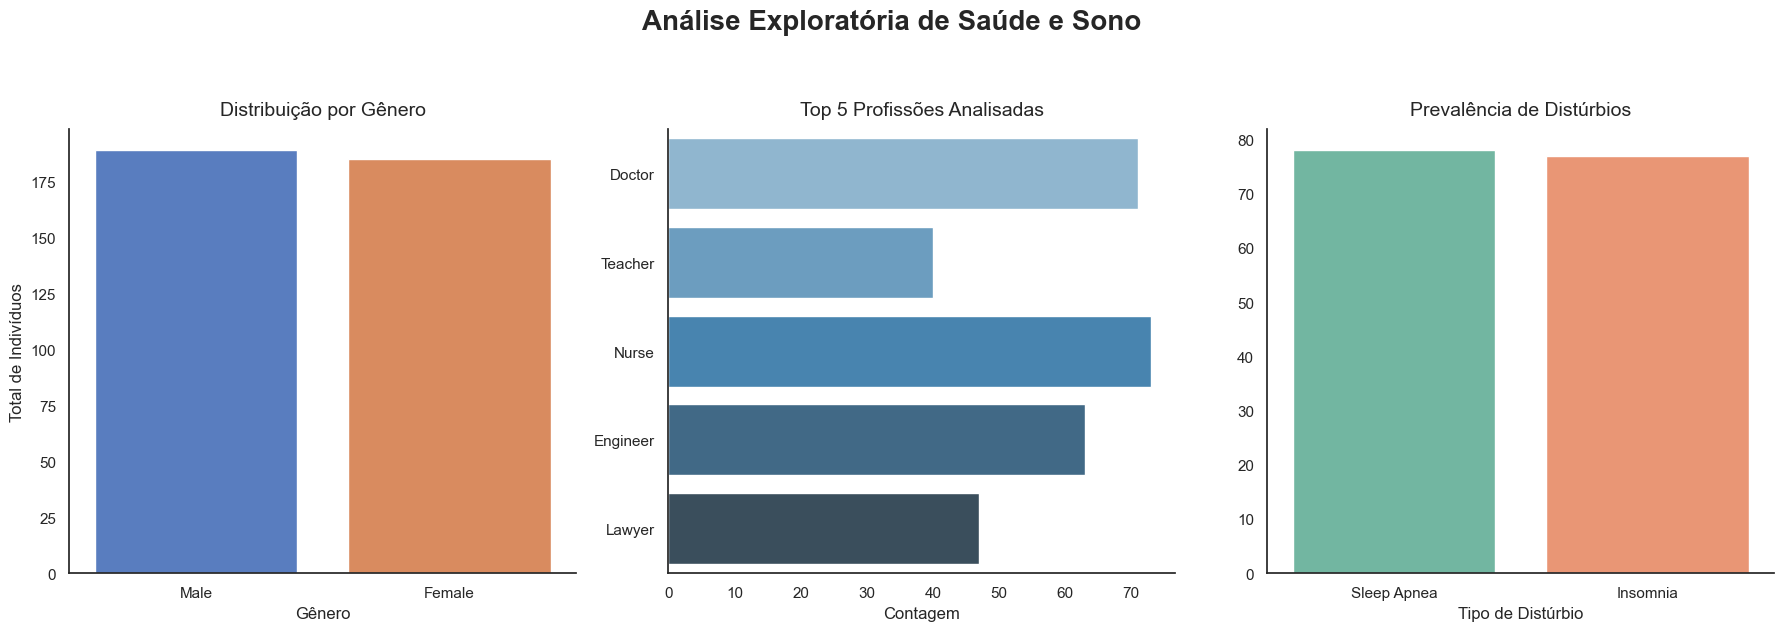

In [12]:
top_occupations = df['Occupation'].value_counts().nlargest(5).index


sns.set_theme(style="white", palette="muted") 
fig, axes = plt.subplots(1, 3, figsize=(18, 6))


fig.suptitle('Análise Exploratória de Saúde e Sono', fontsize=20, fontweight='bold', y=1.05)


sns.countplot(data=df, x='Gender', ax=axes[0], hue='Gender', legend=False)
axes[0].set_title('Distribuição por Gênero', fontsize=14, pad=10)
axes[0].set_xlabel('Gênero')
axes[0].set_ylabel('Total de Indivíduos')



sns.countplot(data=df[df['Occupation'].isin(top_occupations)], 
              y='Occupation', ax=axes[1], hue='Occupation', palette='Blues_d', legend=False)
axes[1].set_title('Top 5 Profissões Analisadas', fontsize=14, pad=10)
axes[1].set_xlabel('Contagem')
axes[1].set_ylabel('') 


sns.countplot(data=df, x='Sleep Disorder', ax=axes[2], hue='Sleep Disorder', palette='Set2', legend=False)
axes[2].set_title('Prevalência de Distúrbios', fontsize=14, pad=10)
axes[2].set_xlabel('Tipo de Distúrbio')
axes[2].set_ylabel('')


sns.despine() 
plt.tight_layout()
plt.show()

A análise gráfica do dataset mostra que há uma distribuição equilibrada entre homens e mulheres, o que eh evita possíveis vieses de gênero no treinamento do modelo. Observamos também que as profissões de Enfermeiro(a), Médico(a) e Contador(a) são as mais frequentes, o que em segunda análise pode fazer com que padrões de sono associados a essas rotinas de trabalho sejam identificados também. Em relação ao nosso target, Sleep Disorder, a maioria dos indíviduos não apresenta distúrbios, porém existem muitos casos de Apneia e Insônia.

## 3. Divisão dos Dados de Treino, Teste e Validação

O `SonoDataModule` é responsável por todo o pipeline de preparação dos dados, desde a leitura do CSV até a entrega dos dados prontos em lotes para o treinamento. Ele unifica o pré-processamento, a divisão e a normalização em um único lugar, garantindo que treino, validação e teste sigam sempre o mesmo fluxo.

In [13]:
class SonoDataModule(L.LightningDataModule):
    
    # Define os parâmetros de configuração do DataModule
    def __init__(
        self,
        tamanho_teste=0.15,   # 15% dos dados para teste
        tamanho_val=0.176,    # ~13% dos dados para validação
        tamanho_lote=32,      # número de amostras por lote (batch)
        num_trabalhadores=0,  # 0 para evitar overhead no Jupyter
        semente_aleatoria=333666, # garante reprodutibilidade
    ):
        super().__init__()
        self.tamanho_teste = tamanho_teste
        self.tamanho_val = tamanho_val
        self.tamanho_lote = tamanho_lote
        self.num_trabalhadores = num_trabalhadores
        self.semente_aleatoria = semente_aleatoria

# ------------- Tratameto dos dados ------------- 

    def setup(self, stage=None):
        df = pd.read_csv('Sleep_health_and_lifestyle_dataset.csv')
        df = df.drop(columns=['Person ID'])
        df[['Systolic', 'Diastolic']] = df['Blood Pressure'].str.split('/', expand=True).astype(int)
        df = df.drop(columns=['Blood Pressure'])
        df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')


        df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})
        df['BMI Category'] = df['BMI Category'].map({'Normal': 0, 'Normal Weight': 0, 'Overweight': 1, 'Obese': 2})
        df['Sleep Disorder'] = df['Sleep Disorder'].map({'None': 0, 'Insomnia': 1, 'Sleep Apnea': 2})
        df = pd.get_dummies(df, columns=['Occupation'], dtype=int)

        X = df.drop(columns=['Sleep Disorder'])
        y = df['Sleep Disorder']
        
        
        self.num_features = X.shape[1] # salva o nº de colunas para construir a rede dinamicamente

        
        indices = df.index
        indices_treino_val, indices_teste = train_test_split(
            indices, test_size=self.tamanho_teste, random_state=self.semente_aleatoria, stratify=y
        )
        
        df_treino_val = df.loc[indices_treino_val]
        df_teste = df.loc[indices_teste]

        indices = df_treino_val.index
        indices_treino, indices_val = train_test_split(
            indices, test_size=self.tamanho_val, random_state=self.semente_aleatoria, stratify=df_treino_val['Sleep Disorder']
        )

        df_treino = df.loc[indices_treino]
        df_val = df.loc[indices_val]

        X_treino = df_treino.drop(columns=['Sleep Disorder']).values
        y_treino = df_treino['Sleep Disorder'].values


        self.x_scaler = MaxAbsScaler()
        self.x_scaler.fit(X_treino)


        if stage == "fit":
            X_val = df_val.drop(columns=['Sleep Disorder']).values
            y_val = df_val['Sleep Disorder'].values

            X_treino = self.x_scaler.transform(X_treino)
            X_val = self.x_scaler.transform(X_val)

            self.X_treino = torch.tensor(X_treino, dtype=torch.float32)
            self.y_treino = torch.tensor(y_treino, dtype=torch.long) # LONG por ser classificação

            self.X_val = torch.tensor(X_val, dtype=torch.float32)
            self.y_val = torch.tensor(y_val, dtype=torch.long)

        if stage == "test":
            X_teste = df_teste.drop(columns=['Sleep Disorder']).values
            y_teste = df_teste['Sleep Disorder'].values

            X_teste = self.x_scaler.transform(X_teste)

            self.X_teste = torch.tensor(X_teste, dtype=torch.float32)
            self.y_teste = torch.tensor(y_teste, dtype=torch.long)


# ------------- Divisão dos Dados ------------- 
    def train_dataloader(self):      
        dataset = TensorDataset(self.X_treino, self.y_treino)
        return DataLoader(dataset, batch_size=self.tamanho_lote,
                          num_workers=self.num_trabalhadores, shuffle=True)

    def val_dataloader(self):
        dataset = TensorDataset(self.X_val, self.y_val)
        return DataLoader(dataset, batch_size=self.tamanho_lote,
                          num_workers=self.num_trabalhadores)

    def test_dataloader(self):
        return DataLoader(
            TensorDataset(self.X_teste, self.y_teste),
            batch_size=self.tamanho_lote * 2, 
            num_workers=self.num_trabalhadores,
            shuffle=False,
        )

### 3.1. Tratamento dos dados

Como a arquitetura de Redes Neurais (MLP) requer um conjunto de dados numéricos, aplicamos alguns tratamentos no dataset:
- A coluna "Blood Pressure", que se refere a pressão diastólica e sistólica do sistema cardiovascular foi dividida em "Systolic" e "Diastolic".
- Os dados ausentes no target foram preenchidos com 'None'
- As categorias de gênero, de Índice de Massa Corporal (IMC), Distúrbio do sono (o target) e Ocupação foram numerizadas. A ultima delas utilizou da técnica de One-Hot Encoding.

### 3.2. Divisão dos dados

Os dados são divididos em três conjuntos:

- **Treino (≈ 72%):** utilizado para ajustar os pesos da rede.
- **Validação (≈ 13%):** utilizado durante o treino para monitorar o desempenho e guiar o Optuna na escolha dos melhores hiperparâmetros.
- **Teste (15%):** separado desde o início e utilizado apenas na avaliação final.

A divisão é feita com `stratify`, garantindo que a proporção de cada classe seja mantida nos três conjuntos. A normalização utiliza `MaxAbsScaler`, fitado **apenas nos dados de treino** e aplicado nos demais, evitando vazamento de informação (*data leakage*).

## 4. Definindo a Arquitetura 

A arquitetura utilizada é uma **MLP (Multilayer Perceptron)** com estrutura flexível, definida dinamicamente pelo processo de otimização de hiperparâmetros. Seus componentes são:

- **Camada de entrada:** tamanho definido automaticamente pelo número de atributos do dataset após o pré-processamento.
- **Camadas escondidas:** o número de camadas (entre 1 e 3) e a quantidade de neurônios em cada uma (entre 8 e 128) são hiperparâmetros otimizados pelo Optuna.
- **Função de ativação:** ReLU (*Rectified Linear Unit*) após cada camada escondida, escolhida por ser computacionalmente eficiente e evitar o problema do gradiente desaparecente.
- **Camada de saída:** 3 neurônios, um para cada classe: Normal (0), Insônia (1) e Apneia do Sono (2).
- **Função de perda:** `CrossEntropyLoss`, adequada para classificação multiclasse pois combina internamente o Softmax com a log-verossimilhança negativa.
- **Otimizador:** Adam, com taxa de aprendizado também otimizada pelo Optuna (entre 1e-4 e 1e-1).

In [14]:
class ModeloSaudeSonoOptuna(L.LightningModule):
    def __init__(self, num_dados_entrada, n_units_list, lr):
        super().__init__()
        
        
        self.lr = lr 
        
        camadas = []
        entrada = num_dados_entrada # começa com o número de features do dataset
        
        for unidades in n_units_list:
            camadas.append(nn.Linear(entrada, unidades)) # camada linear conectando entrada aos neurônios
            camadas.append(nn.ReLU())        # função de ativação
            entrada = unidades # a saída dessa camada vira a entrada da próxima
            
        camadas.append(nn.Linear(entrada, 3)) # camada de saída com 3 neurõnios
        
        self.camadas = nn.Sequential(*camadas) # empilha as camadas em sequencia 

        self.fun_perda = nn.CrossEntropyLoss() # função de perda para classificação multiclasse

    def forward(self, x):
 
        x = self.camadas(x) # passa os dados por todas as camadas em sequência
        return x  # retorna os logits (um valor por classe)

    def configure_optimizers(self):
            # Adam adapta o lr de cada peso com base no histórico de gradientes
            # pesos com gradientes grandes recebem lr menor, e vice-versa
        optimizer = optim.Adam(self.parameters(), lr=self.lr)  
        return optimizer 

    def training_step(self, batch, batch_idx):
        x, y = batch # separa dados de entrada e rótulos reais
        y_pred = self(x) # passa pela rede e obtém as previsões
        loss = self.fun_perda(y_pred, y) # calcula o erro entre previsão e realidade
        self.log("loss", loss, prog_bar=True, on_step=False, on_epoch=True) # registra o erro
        return loss # Lightning usa o erro para atualizar os pesos

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = self.fun_perda(y_pred, y)
        self.log("val_loss", loss, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def test_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = self.fun_perda(y_pred, y)
        self.log("test_loss", loss)
        return loss

Com a classe definida, instanciamos o `DataModule` e preparamos os dados para o treino.

In [15]:
dm = SonoDataModule() # instancia o DataModule com os parâmetros padrão
dm.setup(stage="fit")  # prepara os dados de treino e validação
num_dados_entrada = dm.num_features # salva o nº de features para construir a rede
num_targets = 3

## 5. Otimização de Hiperparâmetros (Optuna)

Para encontrar a melhor arquitetura, utilizamos o **Optuna** com o algoritmo TPE (*Tree-structured Parzen Estimator*), que aprende com os trials anteriores para sugerir combinações cada vez mais promissoras. São testadas 100 arquiteturas diferentes, variando três hiperparâmetros: número de camadas, quantidade de neurônios por camada e taxa de aprendizado.

Para encontrar a melhor arquitetura, utilizamos o **Optuna** com o algoritmo TPE (*Tree-structured Parzen Estimator*), que aprende com os trials anteriores para sugerir combinações cada vez mais promissoras. São testadas 100 arquiteturas diferentes, variando três hiperparâmetros:

- **Número de camadas escondidas (1 a 3)**: redes muito profundas tendem a sofrer com gradiente desaparecente e sobreajuste em datasets pequenos; o limite superior de 3 camadas é suficiente para capturar relações não-lineares sem excesso de complexidade.
- **Neurônios por camada (8 a 128)**: o limite inferior de 8 garante capacidade mínima de representação, enquanto 128 é uma potência de 2 convencional que já supera em muito o número de atributos do dataset (~20).
- **Taxa de aprendizado (1e-4 a 1e-1, escala logarítmica)**: intervalo comum para o otimizador Adam. A escala logarítmica garante que valores pequenos sejam amostrados com a mesma frequência relativa que valores grandes.
Cada trial treina por 10 épocas — valor escolhido para equilibrar o custo computacional de 100 trials com a capacidade de distinguir arquiteturas promissoras das ruins.


In [16]:
def objective(trial):
    # Optuna sugere hiperparâmetros a cada trial
    n_layers = trial.suggest_int("n_layers", 1, 3) # número de camadas escondidas
    n_units_list = [trial.suggest_int(f"n_units_l{i}", 8, 128) for i in range(n_layers)] # neurônios por camada
    lr = trial.suggest_float("lr", 1e-4, 1e-1, log=True) # lr em escala logarítmica
    
    # Instancia o modelo com os hiperparâmetros sugeridos
    modelo = ModeloSaudeSonoOptuna(
        num_dados_entrada=num_dados_entrada, 
        n_units_list=n_units_list, 
        lr=lr
    )

    trainer = L.Trainer(
        max_epochs=10,
        accelerator="auto", 
        enable_progress_bar=False,
        logger=False,
        enable_checkpointing=False
    )
    

    trainer.fit(
    modelo,
    train_dataloaders=dm.train_dataloader(),
    val_dataloaders=dm.val_dataloader()
)
    

    return trainer.callback_metrics["val_loss"].item() # retorna o val_loss para o Optuna avaliar

# Cria o estudo minimizando o val_loss e roda os 100 trials
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f"\nMelhores parâmetros encontrados: {study.best_params}")

[I 2026-04-06 20:08:26,440] A new study created in memory with name: no-name-6e752353-cee7-4995-b9d8-d9a77449d308
  0%|                                                                                          | 0/100 [00:00<?, ?it/s]GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name      | Type             | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | camadas   | Sequential       | 26.4 K | train | 0    
1 | fun_perda | CrossEntropyLoss | 0      | train | 0    
---------------------------------------------------------------
26.4 K    Trainable params
0         Non-trainable params
26.4 K    Total params
0.105     Total estimated model params size (MB)
9         Modules in train mo

[I 2026-04-06 20:08:28,100] Trial 0 finished with value: 0.6633199453353882 and parameters: {'n_layers': 3, 'n_units_l0': 100, 'n_units_l1': 112, 'n_units_l2': 110, 'lr': 0.0009242694291061416}. Best is trial 0 with value: 0.6633199453353882.


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name      | Type             | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | camadas   | Sequential       | 7.3 K  | train | 0    
1 | fun_perda | CrossEntropyLoss | 0      | train | 0    
---------------------------------------------------------------
7.3 K     Trainable params
0         Non-trainable params
7.3 K     Total params
0.029     Total estimated model params size (MB)
7         Modules in train mode
0         Modules in eval mode
0         Total Flops
`Trainer.fit` stopped: `max_epochs=10` reached.
Best trial: 0. Best value: 0.66332:   2%|▉                                             | 2/100 [00:02<02:24,  1.47s/it]

[I 2026-04-06 20:08:29,442] Trial 1 finished with value: 0.6899695992469788 and parameters: {'n_layers': 2, 'n_units_l0': 60, 'n_units_l1': 92, 'lr': 0.000641557006782064}. Best is trial 0 with value: 0.6633199453353882.


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name      | Type             | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | camadas   | Sequential       | 1.2 K  | train | 0    
1 | fun_perda | CrossEntropyLoss | 0      | train | 0    
---------------------------------------------------------------
1.2 K     Trainable params
0         Non-trainable params
1.2 K     Total params
0.005     Total estimated model params size (MB)
5         Modules in train mode
0         Modules in eval mode
0         Total Flops
`Trainer.fit` stopped: `max_epochs=10` reached.
Best trial: 0. Best value: 0.66332:   3%|█▍                                            | 3/100 [00:04<02:08,  1.33s/it]

...

[I 2026-04-06 20:10:29,027] Trial 97 finished with value: 0.6854194402694702 and parameters: {'n_layers': 1, 'n_units_l0': 112, 'lr': 0.0010757719298901197}. Best is trial 62 with value: 0.5284219980239868.


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name      | Type             | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | camadas   | Sequential       | 2.7 K  | train | 0    
1 | fun_perda | CrossEntropyLoss | 0      | train | 0    
---------------------------------------------------------------
2.7 K     Trainable params
0         Non-trainable params
2.7 K     Total params
0.011     Total estimated model params size (MB)
5         Modules in train mode
0         Modules in eval mode
0         Total Flops
`Trainer.fit` stopped: `max_epochs=10` reached.
Best trial: 62. Best value: 0.528422:  99%|██████████████████████████████████████████▌| 99/100 [02:03<00:01,  1.05s/it]

[I 2026-04-06 20:10:29,960] Trial 98 finished with value: 0.588772714138031 and parameters: {'n_layers': 1, 'n_units_l0': 102, 'lr': 0.0034231917601856396}. Best is trial 62 with value: 0.5284219980239868.


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name      | Type             | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | camadas   | Sequential       | 2.1 K  | train | 0    
1 | fun_perda | CrossEntropyLoss | 0      | train | 0    
---------------------------------------------------------------
2.1 K     Trainable params
0         Non-trainable params
2.1 K     Total params
0.008     Total estimated model params size (MB)
5         Modules in train mode
0         Modules in eval mode
0         Total Flops
`Trainer.fit` stopped: `max_epochs=10` reached.
Best trial: 62. Best value: 0.528422: 100%|██████████████████████████████████████████| 100/100 [02:04<00:00,  1.24s/it]

[I 2026-04-06 20:10:30,843] Trial 99 finished with value: 0.5998188257217407 and parameters: {'n_layers': 1, 'n_units_l0': 81, 'lr': 0.0018973655713666606}. Best is trial 62 with value: 0.5284219980239868.

Melhores parâmetros encontrados: {'n_layers': 3, 'n_units_l0': 86, 'n_units_l1': 117, 'n_units_l2': 76, 'lr': 0.00651258986282067}


## 6. Treinamento do Modelo Final

Com os melhores hiperparâmetros encontrados pelo Optuna, treinamos o modelo definitivo por 50 épocas para que a rede tenha tempo suficiente para convergir.

In [8]:
# Recupera os melhores hiperparâmetros encontrados pelo Optuna
melhores_params = study.best_params

# Monta a lista de neurônios por camada a partir dos melhores parâmetros
n_units_list = [melhores_params[f"n_units_l{i}"] for i in range(melhores_params["n_layers"])]

# Instancia o modelo definitivo com os melhores hiperparâmetros
modelo = ModeloSaudeSonoOptuna(
    num_dados_entrada=num_dados_entrada,
    n_units_list=n_units_list,
    lr=melhores_params["lr"]
)

# Treina o modelo final com 50 épocas
trainer_final = L.Trainer(max_epochs=50, accelerator="auto")
trainer_final.fit(
    modelo,
    train_dataloaders=dm.train_dataloader(),
    val_dataloaders=dm.val_dataloader()
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
C:\Users\victor25015\AppData\Roaming\Python\Python312\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint,

C:\Users\victor25015\AppData\Roaming\Python\Python312\site-packages\lightning\pytorch\loops\fit_loop.py:317: The number of training batches (9) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 0: 100%|██████████████████████████████████████████████████████████████████| 9/9 [00:00<00:00, 51.35it/s, v_num=0]
Validation: |                                                                                    | 0/? [00:00<?, ?it/s]
Validation: |                                                                                    | 0/? [00:00<?, ?it/s]
Epoch 1: 100%|██████████████████████████████████████| 9/9 [00:00<00:00, 75.36it/s, v_num=0, val_loss=0.885, loss=0.881]
Validation: |                                                                                    | 0/? [00:00<?, ?it/s]
Validation: |                                                                                    | 0/? [00:00<?, ?it/s]
Epoch 2: 100%|██████████████████████████████████████| 9/9 [00:00<00:00, 69.53it/s, v_num=0, val_loss=1.120, loss=0.686]
Validation: |                                                                                    | 0/? [00:00<?, ?it/s]
Validation: |                           

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|█████████████████████████████████████| 9/9 [00:00<00:00, 25.64it/s, v_num=0, val_loss=0.701, loss=0.340]


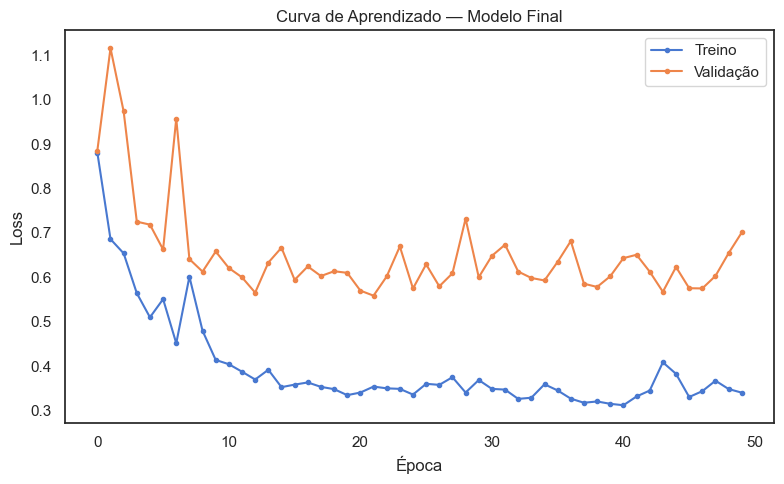

In [17]:
import os
# Encontra a versão mais recente do lightning_logs (modelo final)
log_dir = "lightning_logs"
versoes = sorted(os.listdir(log_dir))
ultima_versao = versoes[-1]
caminho_csv = os.path.join(log_dir, ultima_versao, "metrics.csv")

# Lê o histórico de métricas
df_metricas = pd.read_csv(caminho_csv)

# Separa loss de treino e validação por época
loss_treino = df_metricas.dropna(subset=["loss"]).groupby("epoch")["loss"].mean()
loss_val = df_metricas.dropna(subset=["val_loss"]).groupby("epoch")["val_loss"].mean()

# Plota a curva de aprendizado
plt.figure(figsize=(8, 5))
plt.plot(loss_treino.index, loss_treino.values, label="Treino", marker="o", markersize=3)
plt.plot(loss_val.index, loss_val.values, label="Validação", marker="o", markersize=3)
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Curva de Aprendizado — Modelo Final")
plt.legend()
plt.tight_layout()
plt.show()

A curva de aprendizado mostra que a loss de treino converge de forma estável ao longo das 50 épocas, atingindo valores em torno de 0.33. A loss de validação, por sua vez, cai rapidamente nas primeiras épocas mas permanece oscilatória e consideravelmente mais alta (~0.6), o que indica um grau de sobreajuste (overfitting): o modelo aprende bem os dados de treino mas generaliza com menos precisão para dados novos.

## 7. Avaliação do Modelo

Com o modelo treinado, avaliamos seu desempenho no conjunto de teste (dados que a rede nunca viu durante o treino ou a otimização). A matriz de confusão mostra a distribuição dos acertos e erros por classe, e o relatório traz as métricas de precisão, recall e F1-score para cada uma delas.

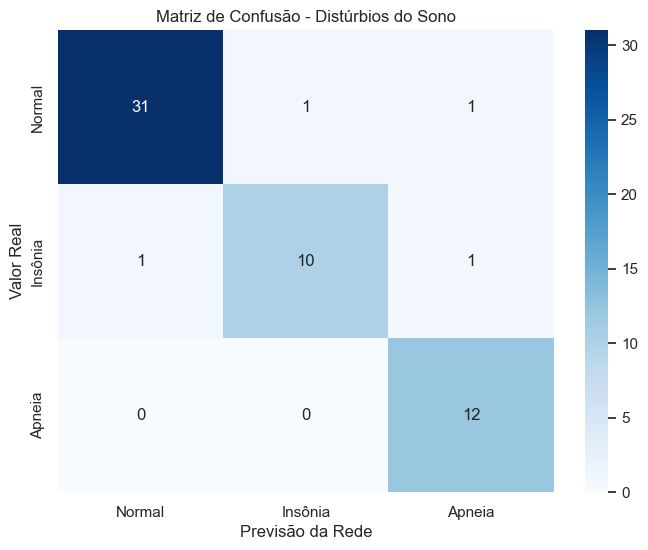


Relatório de Classificação:

              precision    recall  f1-score   support

      Normal       0.97      0.94      0.95        33
     Insônia       0.91      0.83      0.87        12
      Apneia       0.86      1.00      0.92        12

    accuracy                           0.93        57
   macro avg       0.91      0.92      0.92        57
weighted avg       0.93      0.93      0.93        57



In [18]:
dm.setup(stage="test") # prepara os dados de teste com o mesmo scaler do treino

modelo.eval() # coloca o modelo em modo de avaliação
with torch.no_grad(): # delsiga o cálculo dos gradientes
    logits = modelo(dm.X_teste) # passa os dados pela rede o obtem os logits
    previsoes = torch.argmax(logits, dim=1) # escolhe a classe com maior logit para previsão

cm = confusion_matrix(dm.y_teste, previsoes) #gera a matriz de confusão, comparando as previsões com os rótulos reais.

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Insônia', 'Apneia'],
            yticklabels=['Normal', 'Insônia', 'Apneia'])
plt.xlabel('Previsão da Rede')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusão - Distúrbios do Sono')
plt.show()

print("\nRelatório de Classificação:\n")
print(classification_report(dm.y_teste, previsoes,
                             target_names=['Normal', 'Insônia', 'Apneia']))

## 8. Comparação com Floresta Aleatória

Para contextualizar o desempenho da rede neural, comparamos seus resultados com uma **Floresta Aleatória** (*Random Forest*), um algoritmo clássico de aprendizado de máquina bastante competitivo em dados tabulares. Diferente da MLP, a Floresta Aleatória não requer normalização dos dados nem otimização extensa de hiperparâmetros, o que a torna uma alternativa simples e eficiente para problemas como este.

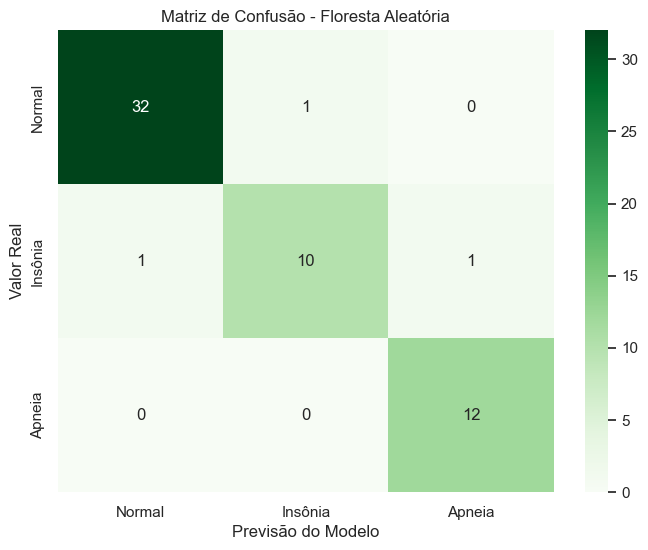


Relatório de Classificação - Floresta Aleatória:

              precision    recall  f1-score   support

      Normal       0.97      0.97      0.97        33
     Insônia       0.91      0.83      0.87        12
      Apneia       0.92      1.00      0.96        12

    accuracy                           0.95        57
   macro avg       0.93      0.93      0.93        57
weighted avg       0.95      0.95      0.95        57



In [19]:
# Converter tensores para numpy para uso no sklearn
X_treino_np = dm.X_treino.numpy()
X_teste_np  = dm.X_teste.numpy()
y_treino_np = dm.y_treino.numpy()
y_teste_np  = dm.y_teste.numpy()


# Treinar a floresta aleatória nos mesmos dados de treino
rf = RandomForestClassifier(n_estimators=100, random_state=333666)
rf.fit(X_treino_np, y_treino_np)

# Previsões no conjunto de teste
previsoes_rf = rf.predict(X_teste_np)

# Matriz de Confusão
cm_rf = confusion_matrix(y_teste_np, previsoes_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normal', 'Insônia', 'Apneia'],
            yticklabels=['Normal', 'Insônia', 'Apneia'])
plt.xlabel('Previsão do Modelo')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusão - Floresta Aleatória')
plt.show()

print("\nRelatório de Classificação - Floresta Aleatória:\n")
print(classification_report(y_teste_np, previsoes_rf, target_names=['Normal', 'Insônia', 'Apneia']))

## 9. Análise Comparativa


In [20]:
from sklearn.metrics import accuracy_score

acuracia_mlp = accuracy_score(dm.y_teste, previsoes)
acuracia_rf = accuracy_score(y_teste_np, previsoes_rf)

print(f"Acurácia MLP:               {acuracia_mlp:.2f}")
print(f"Acurácia Floresta Aleatória: {acuracia_rf:.2f}")

Acurácia MLP:               0.93
Acurácia Floresta Aleatória: 0.95


| Métrica | MLP (Optuna) | Floresta Aleatória |
|---|---|---|
| Acurácia geral | 0.93 | **0.95** |
| F1 — Normal | 0.95 | **0.97** |
| F1 — Insônia | 0.87 | 0.87 |
| F1 — Apneia | 0.92 | **0.96** |

A Floresta Aleatória apresentou desempenho ligeiramente superior à rede neural MLP, atingindo 95% de acurácia contra 93% da MLP. Ambos os modelos tiveram dificuldade semelhante com a classe Insônia (F1 = 0.87), que é a mais difícil de separar das demais — possivelmente por ser a classe com menos exemplos no dataset.

Vale destacar que a Floresta Aleatória não errou nenhum caso de Apneia (recall = 1.00) e cometeu apenas 3 erros no total, enquanto a MLP cometeu 4. 
Considerando que a Floresta Aleatória é um modelo mais simples de treinar e não requer otimização de hiperparâmetros tão extensa, ela se mostrou uma alternativa competitiva para este problema específico.

Isso é um resultado comum em datasets tabulares de tamanho pequeno-médio, onde algoritmos baseados em árvores tendem a ser muito eficientes.

Além disso, esta comparação não é inteiramente equilibrada: enquanto a MLP passou por um processo extenso de otimização de hiperparâmetros com 100 trials via Optuna, a Floresta Aleatória foi treinada com parâmetros padrão (n_estimators=100). Uma comparação mais justa envolveria otimizar também os hiperparâmetros da Floresta Aleatória, como o número de estimadores, a profundidade máxima das árvores e o critério de divisão. Ainda assim, a comparação é válida como referência de baseline.

## 10. Conclusão

Neste trabalho, construímos e otimizamos uma rede neural MLP para classificar distúrbios do sono em três categorias — Normal, Insônia e Apneia do Sono — com base em dados de saúde e estilo de vida.

Utilizando o Optuna com o algoritmo TPE, testamos 100 arquiteturas diferentes, variando o número de camadas (1 a 3), a quantidade de neurônios por camada (8 a 128) e a taxa de aprendizado (1e-4 a 1e-1). A melhor arquitetura encontrada foi uma rede com 1 camada escondida de 26 neurônios e taxa de aprendizado de ~0.005, atingindo **93% de acurácia** no conjunto de teste.

A comparação com a Floresta Aleatória revelou que, para este problema específico, o modelo clássico foi ligeiramente superior, atingindo **95% de acurácia**. Isso é esperado dado o tamanho reduzido do dataset (~370 exemplos), onde algoritmos baseados em árvores tendem a ser mais eficientes que redes neurais, que geralmente se beneficiam de volumes maiores de dados.

Ambos os modelos apresentaram maior dificuldade com a classe **Insônia** (F1 = 0.87 nos dois casos), provavelmente por ser a classe com menos exemplos e maior sobreposição de características com as demais. A classe **Apneia** foi a mais fácil de identificar, com recall de 1.00 em ambos os modelos: nenhum caso de Apneia foi classificado erroneamente como outra coisa.

Como trabalhos futuros, seria interessante explorar técnicas de regularização como dropout e early stopping para reduzir o sobreajuste da MLP, além de coletar mais dados para verificar se a rede neural consegue superar a Floresta Aleatória em um dataset maior.

## 11. Referências

CASSAR, Daniel Roberto. ATP-303 NN 1.1 - Notebook derivadas (2). Campinas: Ilum Escola de Ciência, 2026. Jupyter Notebook.

CASSAR, Daniel Roberto. ATP-303 NN 2.1 - Classes em Python (2). Campinas: Ilum Escola de Ciência, 2026. Jupyter Notebook.

CASSAR, Daniel Roberto. ATP-303 NN 2.4 - Multilayer Perceptron em Python puro (4). Campinas: Ilum Escola de Ciência, 2026. Jupyter Notebook.

CASSAR, Daniel Roberto. ATP-303 NN 3.2 - Construindo e treinando redes neurais com PyTorch e Lightning. Campinas: Ilum Escola de Ciência, 2026. Jupyter Notebook.

CASSAR, Daniel Roberto. ATP-203 4.0 - Árvore de decisão e floresta aleatória (1). Campinas: Ilum Escola de Ciência, 2025. Jupyter Notebook.

CASSAR, Daniel Roberto. ATP-203 7.2 - Otimização de hiperparâmetros com optuna. Campinas: Ilum Escola de Ciência, 2025. Jupyter Notebook.

GOOGLE. Gemini: resposta a pergunta sobre pré-processamento de pressão arterial e otimização com Optuna. [S. l.], 29 mar. 2026. Chatbot. Disponível em: https://gemini.google.com/share/a944b4f6e662. Acesso em: 29 mar. 2026.

DATAMLISTIC. Dropout in Neural Networks - Explained. YouTube, 23 fev. 2025. Disponível em: https://www.youtube.com/watch?v=FDF_Q3_98GQ. Acesso em: 29 mar. 2026.

DATAMLISTIC. Dropout in Neural Networks - Explained. YouTube, 23 fev. 2025. Disponível em: https://www.youtube.com/watch?v=FDF_Q3_98GQ. Acesso em: 29 mar. 2026.

RYAN & MATT DATA SCIENCE. Mastering Hyperparameter Tuning with Optuna: Boost Your Machine Learning Models!. YouTube, 30 out. 2023. Disponível em: https://www.youtube.com/watch?v=t-INgABWULw. Acesso em: 29 mar. 2026.